In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on sys.path so ml_toolbox imports resolve when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml_toolbox.signal_processing.spectrum_analysis import compute_fft_spectrum, find_spectral_peaks
from ml_toolbox.data_loader.features.frequency_domain import FrequencyDomainFeatures

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})


def make_signal(f0: float = 50.0,
                harmonics: dict[int, float] | None = None,
                noise_std: float = 0.02,
                duration: float = 1.0,
                fs: float = 5000.0) -> tuple[np.ndarray, np.ndarray]:
    """Create synthetic fundamental + harmonics + white noise signal."""
    harmonics = harmonics or {2: 0.35, 3: 0.2}
    t = np.arange(0, duration, 1 / fs)
    signal = np.sin(2 * np.pi * f0 * t)
    for k, amp in harmonics.items():
        signal += amp * np.sin(2 * np.pi * f0 * k * t)
    if noise_std > 0:
        signal += noise_std * np.random.randn(t.size)
    return t, signal


def analyze_once(f0: float = 50.0,
                 harmonics: dict[int, float] | None = None,
                 noise_std: float = 0.02,
                 fs: float = 5000.0,
                 duration: float = 1.0,
                 nperseg: int | None = 2048,
                 prominence: float | None = 0.05,
                 max_harmonics: int = 5,
                 tolerance_factor: float = 0.05):
    """Generate signal, compute spectrum/peaks, and harmonic features."""
    t, signal = make_signal(f0=f0, harmonics=harmonics, noise_std=noise_std, duration=duration, fs=fs)
    spectrum = compute_fft_spectrum(signal, sampling_rate=fs, nperseg=nperseg, normalize=True)
    peaks = find_spectral_peaks(spectrum, prominence=prominence, num_peaks=12)

    # Shape inputs to the harmonic feature helper
    spectrum_dict = {"freqs": spectrum["freqs"], "magnitude": spectrum["magnitude"]}
    peaks_dict = {"peak_freqs": peaks["peak_freqs"],
                  "peak_magnitudes": peaks["peak_magnitudes"],
                  "peak_indices": peaks["peak_indices"]}

    feats = FrequencyDomainFeatures.harmonic_analysis_features(
        spectrum=spectrum_dict,
        peaks=peaks_dict,
        f0=f0,
        max_harmonics=max_harmonics,
        tolerance_factor=tolerance_factor,
    )
    return t, signal, spectrum, peaks, feats


{'thd_power_frac': 0.512, 'fundamental_power_ratio': 0.4109}


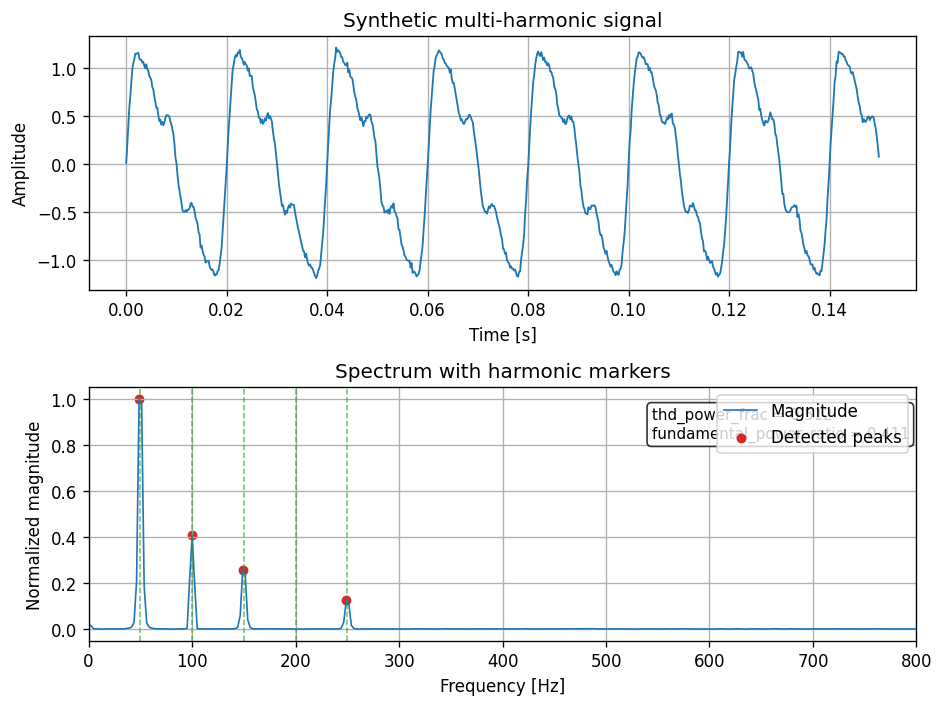

In [2]:
# Single synthetic example: visualize thd_power_frac and fundamental_power_ratio
f0 = 50.0
harmonics = {2: 0.35, 3: 0.25, 5: 0.12}

_, signal, spectrum, peaks, feats = analyze_once(
    f0=f0,
    harmonics=harmonics,
    noise_std=0.02,
    fs=5000.0,
    duration=1.0,
    nperseg=2048,
    prominence=0.03,
    max_harmonics=5,
    tolerance_factor=0.05,
)

print({k: round(v, 4) for k, v in feats.items() if k in ("thd_power_frac", "fundamental_power_ratio")})

freqs = spectrum["freqs"]
magnitude = spectrum["magnitude"]

fig, (ax_time, ax_spec) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)

# Time-domain (show first 0.15 s for readability)
samples_to_show = int(0.15 * spectrum["sampling_rate"])
time_axis = np.arange(samples_to_show) / spectrum["sampling_rate"]
ax_time.plot(time_axis, signal[:samples_to_show], lw=1.1)
ax_time.set_xlabel("Time [s]")
ax_time.set_ylabel("Amplitude")
ax_time.set_title("Synthetic multi-harmonic signal")

# Spectrum with peaks and harmonic markers
ax_spec.plot(freqs, magnitude, label="Magnitude", lw=1.0)
ax_spec.scatter(peaks["peak_freqs"], peaks["peak_magnitudes"], color="tab:red", s=24, label="Detected peaks")

harmonic_freqs = np.array([n * f0 for n in range(1, 6)])
for hf in harmonic_freqs:
    ax_spec.axvline(hf, color="tab:green", ls="--", lw=0.9, alpha=0.7)

ax_spec.set_xlim(0, 800)
ax_spec.set_xlabel("Frequency [Hz]")
ax_spec.set_ylabel("Normalized magnitude")
ax_spec.set_title("Spectrum with harmonic markers")
ax_spec.legend(loc="upper right")

metrics_text = (f"thd_power_frac = {feats['thd_power_frac']:.3f}\n"
                f"fundamental_power_ratio = {feats['fundamental_power_ratio']:.3f}")
ax_spec.text(0.68, 0.8, metrics_text, transform=ax_spec.transAxes,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8), fontsize=9)

plt.tight_layout()
plt.show()


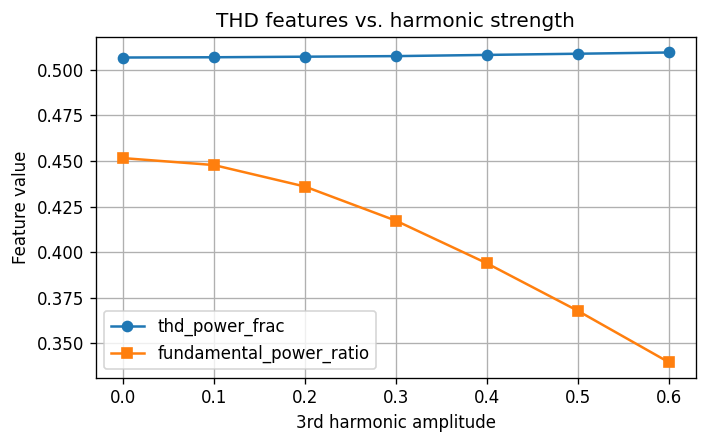

In [3]:
# Sweep third-harmonic amplitude to show metric trend
harm_amp_grid = np.linspace(0.0, 0.6, 7)
thd_vals, fund_ratio_vals = [], []

for a3 in harm_amp_grid:
    _, _, spectrum, peaks, feats = analyze_once(
        f0=f0,
        harmonics={2: 0.3, 3: float(a3)},
        noise_std=0.02,
        fs=5000.0,
        duration=1.0,
        nperseg=2048,
        prominence=0.03,
        max_harmonics=5,
        tolerance_factor=0.05,
    )
    thd_vals.append(feats["thd_power_frac"])
    fund_ratio_vals.append(feats["fundamental_power_ratio"])

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(harm_amp_grid, thd_vals, marker="o", label="thd_power_frac")
ax.plot(harm_amp_grid, fund_ratio_vals, marker="s", label="fundamental_power_ratio")
ax.set_xlabel("3rd harmonic amplitude")
ax.set_ylabel("Feature value")
ax.set_title("THD features vs. harmonic strength")
ax.legend()
plt.tight_layout()
plt.show()
